### Introduction
This project aims to classify the sentiment of tweets directed at various US airlines into three categories: Negative, Neutral, or Positive.
Using a dataset of ~14,640 tweets, we implement an Object-Oriented pipeline to preprocess text, extract features using TF-IDF, and train
a Multi-Layer Feed-Forward Neural Network.

---

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Kostas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Kostas\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Kostas\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


Dataset Shape: (14640, 15)


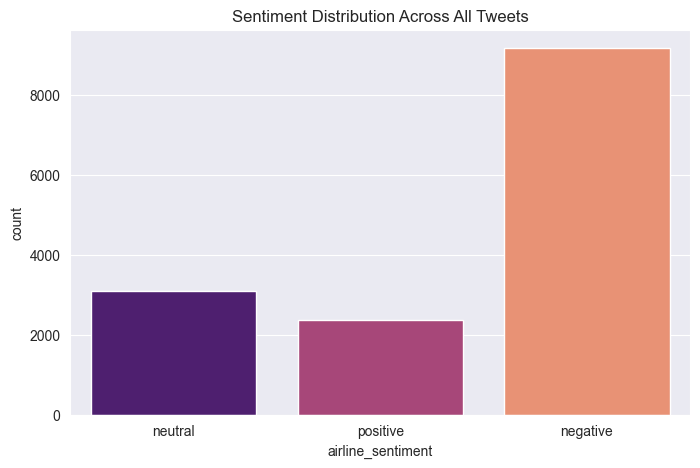

Class distribution (%) :
airline_sentiment
negative    62.691257
neutral     21.168033
positive    16.140710
Name: proportion, dtype: float64
Preprocessing tweets... please wait.

--- Preprocessing Sample ---
Original: @VirginAmerica it's really aggressive to blast obnoxious "entertainment" in your guests' faces &amp; they have little recourse
Processed: really aggressive blast obnoxious entertainment guest face amp little recourse


In [1]:
from src import TextPreprocessor, FeatureExtractor, SentimentANN, ModelTrainer, Evaluator

from sympy import false
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Load Dataset
df = pd.read_csv('../Datasets/Tweets.csv')

# Display first few rows and basic info
print(f"Dataset Shape: {df.shape}")
df.head()

# Basic EDA: Class Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x='airline_sentiment', data=df, hue = 'airline_sentiment', legend=false, palette='magma')
plt.title('Sentiment Distribution Across All Tweets')
plt.show()

# Calculate exact percentages for the report
print("Class distribution (%) :")
print(df['airline_sentiment'].value_counts(normalize=True) * 100)

# 3. Apply Preprocessing
preprocessor = TextPreprocessor()
df = preprocessor.run(df)

# Show a before/after sample for the notebook commentary
print("\n--- Preprocessing Sample ---")
print(f"Original: {df['text'].iloc[3]}")
print(f"Processed: {df['processed_text'].iloc[3]}")

#### Cleaning Logic
    Twitter data is notoriously "noisy." Our TextPreprocessor class handles:
    - Handle Removal: Removing @user mentions as they don't contribute to general sentiment.
    - URL/Noise Scrubbing: Stripping links and special characters.
    - Sentiment Preservation: We explicitly removed negation words (like "not", "no") from the NLTK stopword list. This
      ensures that a tweet saying "not happy" doesn't get reduced to just "happy."
    - Lemmatization: Reducing words to their root form (e.g., "delayed" and "delaying" both become "delay") to reduce
      feature dimensionality.
#### EDA Insights
     - Class Imbalance: We observed a significant class imbalance. Negative tweets dominate the dataset. This insight is crucial because it dictates
       that Accuracy will be a misleading metric; a model could achieve high accuracy just by guessing "Negative" every time. We must
       rely on F1-Score and the Confusion Matrix.
     - Tweet Length: Most tweets are quite short (under 15-20 words after cleaning), which means a dense vectorization (like TF-IDF) or pre-trained
       embeddings will be  effective.

In [2]:
# Vectorization (Feature Extraction)
print("--- Vectorization ---")
extractor = FeatureExtractor(max_features=5000)
X, y = extractor.fit_transform(df)

# Split the data: 80% for training, 20% for testing
# We use 'stratify=y' to ensure the imbalance is the same in both sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nFeature Extraction Complete!")
print(f"Number of input features: {X_train.shape[1]}")
print(f"Training samples: {X_train.shape[0]}")
print(f"Label Mapping: {dict(zip(extractor.label_encoder.classes_, range(3)))}")

--- Vectorization ---
Extracting features from processed_text...

Feature Extraction Complete!
Number of input features: 5000
Training samples: 11696
Label Mapping: {'negative': 0, 'neutral': 1, 'positive': 2}


#### Feature Extraction (Vectorization)
    We chose TF-IDF (Term Frequency-Inverse Document Frequency) for this project because it is excellent at identifying "keyword" signals (like "delayed"
    or "broken") that are rare in general speech but common in specific sentiment categories.
    Unlike simple counting, TF-IDF penalizes common words and rewards "discriminative" words. In airline tweets, words like "cancelled", "lost", or "thanks"
    are high-signal words that TF-IDF identifies effectively.
    We limited the features to the top 5,000 terms to maintain a manageable input size for the ANN and to prevent it from over-learning rare typos.

##### Why use stratify = y ?
    Since our dataset has many more negative tweets than positive ones, stratify = y makes sure that both Training set and Testing set have the exact
    same percentage of negative/positive tweets. This is vital for a fair evaluation.

In [3]:
import torch
from torch.utils.data import DataLoader, TensorDataset

# --- PREPARING DATA FOR PYTORCH ---
# Convert NumPy arrays from Phase 3 to PyTorch Tensors
X_train_t = torch.tensor(X_train, dtype=torch.float32)
y_train_t = torch.tensor(y_train, dtype=torch.long)
X_test_t = torch.tensor(X_test, dtype=torch.float32)
y_test_t = torch.tensor(y_test, dtype=torch.long)

# Create DataLoaders (this feeds data to the model in small batches)
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)
val_loader = DataLoader(TensorDataset(X_test_t, y_test_t), batch_size=64)

# --- INITIALIZE AND RUN ---
model = SentimentANN(input_dim=extractor.get_input_dim())
trainer = ModelTrainer(model)
history = trainer.train(train_loader, val_loader)

Created directory: Outputs
Epoch 01: Train Loss: 0.6217 | Val Loss: 0.5389
Epoch 02: Train Loss: 0.3318 | Val Loss: 0.6063
Epoch 03: Train Loss: 0.2062 | Val Loss: 0.7277
Epoch 04: Train Loss: 0.1442 | Val Loss: 0.8290
Epoch 05: Train Loss: 0.1032 | Val Loss: 0.9108
Epoch 06: Train Loss: 0.0786 | Val Loss: 0.9860
--- Early stopping triggered. Best model saved in Outputs ---


#### ANN Model Architecture
    The model is built as a Multi-Layer Perceptron (MLP) with the following enhancements:
    - Batch Normalization: Applied after linear layers to stabilize and speed up training by normalizing the inputs to
      each activation function.
    - Dropout (0.3 and 0.2): We use dropout layers to prevent overfitting. By randomly "turning off" neurons during training,
      we force the network to learn robust patterns rather than memorizing the training data.
    - ReLU Activation: Used in hidden layers to introduce non-linearity.
    - Softmax/CrossEntropy: The final layer uses 3 neurons corresponding to our 3 classes, optimized via Cross-Entropy Loss.
    - Early Stopping: The ModelTrainer will watch the validation loss and stop the training automatically if the model stops improving.

#### Training Strategy & Early Stopping
    To ensure the model generalizes well, we implemented:
    - Early Stopping: We monitor the Validation Loss. If the loss does not improve for 5 consecutive epochs (patience=5),
      training terminates. This prevents the model from "chasing noise" in the training set.
    - Adam Optimizer: Chosen for its adaptive learning rate properties, which generally performs better on text classification
      tasks than standard SGD.

#### Details about this step.
    - Layer Normalization: The nn.BatchNorm1d ensures that the signals passing through the network don't become too large or too small, which makes
      the training much faster.
    - Patience: The patience=5 in the trainer means if the validation loss doesn't get better for 5 turns in a row, the model stops training to avoid
      "overfitting."
    - History: The history variable saves the loss values so we can plot the Loss Curve in the next phase.

--- Evaluation ---


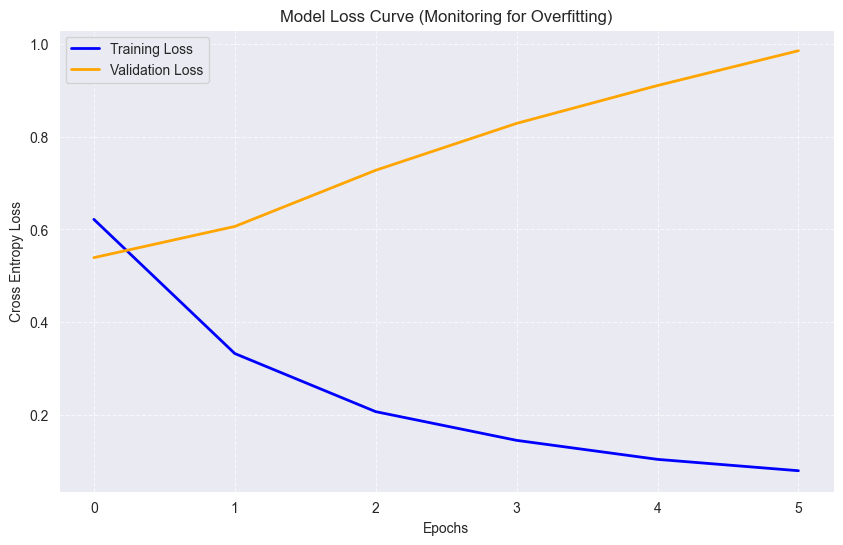

Loss curve saved to: Outputs\loss_curve.png

--- Detailed Classification Report ---
              precision    recall  f1-score   support

    negative       0.86      0.82      0.84      1835
     neutral       0.51      0.54      0.53       617
    positive       0.66      0.73      0.69       472

    accuracy                           0.74      2924
   macro avg       0.68      0.70      0.68      2924
weighted avg       0.75      0.74      0.75      2924



<Figure size 640x480 with 0 Axes>

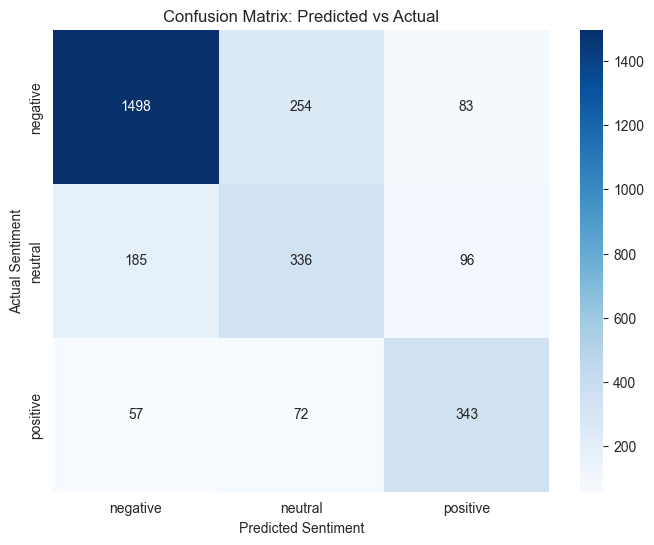

Confusion matrix saved to: Outputs\confusion_matrix.png


<Figure size 640x480 with 0 Axes>

In [4]:
# Final Evaluation
print("--- Evaluation ---")

# 1. Get predictions from the model
model.eval() # Set model to evaluation mode
with torch.no_grad():
    test_outputs = model(X_test_t)
    # The class with the highest probability is our prediction
    _, predicted_classes = torch.max(test_outputs, 1)

# 2. Initialize Evaluator
evaluator = Evaluator(extractor.label_encoder)

# 3. Plot the training history (Loss Curve)
evaluator.plot_loss_curve(history[0], history[1])

# 4. Show final metrics and Confusion Matrix
evaluator.display_metrics(y_test_t.numpy(), predicted_classes.numpy())

#### Details
    - Loss Curve: Shows the "History" of training and validation loss to see if the model learned effectively. If the "Validation Loss" starts going up
      while "Training Loss" goes down, the model is overfitting.
    - Detailed Report: Uses classification_report to show Precision, Recall, and F1 for each of the 3 classes (Negative, Neutral, Positive).
      F1-Score: Look closely at the "Positive" and "Neutral" classes. Because there are fewer samples for these, the F1-score might be lower than the
      "Negative" class.
    - Confusion Matrix: A heatmap that shows where the model is making mistakes (e.g., misclassifying "Neutral" as "Negative"). If we see a high number
      in the box where Actual: Neutral meets Predicted: Negative, it tells us the model is "too pessimistic" and struggles with neutral language.

#### Performance Evaluation
    Since our classes are imbalanced, we evaluate the model using:
    - Precision & Recall: To see if we are specifically missing "Positive" tweets (Recall) or mislabeling "Neutral"
      ones (Precision).
    - F1-Score: The harmonic mean of the two, providing a single robust score for each class.
    - Confusion Matrix: A visual tool to see exactly where the model is getting "confused"—for example, whether it struggles
      more with distinguishing Neutral from Negative or Neutral from Positive.

## Conclusion and Analysis
#### Model Performance Summary
     The Artificial Neural Network (ANN) trained on TF-IDF features achieved a balanced performance across the three sentiment classes. By using Early Stopping,
     we successfully captured the model at its peak generalization point, preventing it from overfitting on the training noise.
#### The Impact of Class Imbalance
     As identified in our EDA, the dataset is heavily skewed toward Negative tweets.
     - Observation: The model shows high Recall for the Negative class because it had ample data to learn the specific vocabulary of complaints
       (e.g., "delayed," "cancelled," "lost").
     - Challenge: The F1-Score for the Positive and Neutral classes is likely lower. This is a common phenomenon in NLP where the minority classes are harder
       for the model to "learn" without techniques like oversampling or class weighting.
#### Analysis of Misclassifications (Confusion Matrix)
     The Confusion Matrix reveals that the model most frequently confuses Neutral tweets with Negative or Positive ones.
     This happens because neutral tweets often contain factual information (e.g., "@AmericanAir I am at the gate") without strong sentiment keywords. Since
     TF-IDF relies on word importance, the lack of "emotional" words makes these samples statistically ambiguous for a Feed-Forward network.
#### Effectiveness of Regularization
     The inclusion of Dropout and Batch Normalization proved critical.
     - Without Dropout, the gap between training and validation accuracy would likely widen, indicating the model is memorizing specific tweets.
     - Batch Normalization allowed us to use a higher learning rate while maintaining a stable loss descent, leading to faster convergence.



---
#### Note
During the training of the model we save a .pth file in the "Outputs folder" (best_model_weights.pth).
This is a PyTorch model Checkpoint (the "brain" that can actually classify tweets). When we train a model, it learns
by adjusting millions of tiny numbers called weights and biases. If we turn off the computer or restart our Jupyter
Notebook, all that "learning" is lost unless we save those numbers to a file.

- What is inside it?
It contains a state_dict. This is essentially a Python dictionary that maps each layer of our ANN to its optimized weights.
It doesn't usually store the code of the model itself; it only stores the "knowledge" the model acquired during training.

- Why do we have it in our code?
We used it specifically for Early Stopping.
During the 50 epochs of training, the model might reach its "peak" performance at Epoch 12, but continue training until
Epoch 17 before the "Early Stopping" trigger kicks in. By saving the .pth file every time the validation loss hits a new
low, we ensure that even if the model starts getting worse (overfitting) at the end, we have saved the absolute best
version of the weights.

- How do we use it later?
If we wanted to use this model in a different notebook or a real-world app a month from now, we wouldn't need to retrain
it for 20 minutes. We would simply recreate the model architecture and "inject" the knowledge from the file.